### `plot_event_display`

In [13]:
%reload_ext autoreload
%autoreload 2

In [14]:
import yaml
from pathlib import Path

import sys
import os
# Manually point to the 'src' folder
sys.path.insert(0, "/home/xzcapnai/hepattn/hepattn/src")

from hepattn.experiments.mu3e.data import Mu3eDataModule

In [15]:
!pwd

/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/visualisation


In [16]:
config_path = Path('/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/configs/mu3e_tracking.yaml')
out_dir = Path('/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/visualisation/plots')
out_dir.mkdir(parents=True, exist_ok=True)

In [17]:
with config_path.open() as f:
    config = yaml.safe_load(f)

In [18]:
dm = Mu3eDataModule(**dict(config["data"]))
dm.setup("fit")
loader = dm.train_dataloader()

Created training dataset with 18,749 events
Created validation dataset with 3,125 events


In [19]:
inputs, targets = next(iter(loader))

In [20]:
print(f"hit_valid shape: {targets['hit_valid'].shape}")
print(f"particle_valid shape: {targets['particle_valid'].shape}")
print(f"particle_hit_valid shape: {targets['particle_hit_valid'].shape}")
print(f"hit_succession_mask shape: {targets['hit_succession_mask'].shape}")

hit_valid shape: torch.Size([100, 207])
particle_valid shape: torch.Size([100, 25])
particle_hit_valid shape: torch.Size([100, 25, 207])
hit_succession_mask shape: torch.Size([100, 207, 207])


### `event_display`

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Polygon
import math

In [30]:
print(f'input tensor keys : {inputs.keys()}')
print(f'target tensor keys : {targets.keys()}')
print()
print(f"particle_hit_valid shape : {targets['particle_hit_valid'].shape}")
print(f"hit tensor shape : {inputs['hit_x'].shape}")

input tensor keys : dict_keys(['hit_valid', 'hit_x', 'hit_y', 'hit_z', 'hit_r', 'hit_s', 'hit_lambda', 'hit_coslambda', 'hit_sinlambda', 'hit_phi', 'hit_cosphi', 'hit_sinphi', 'hit_eta', 'hit_u', 'hit_v', 'hit_hitID'])
target tensor keys : dict_keys(['hit_valid', 'particle_valid', 'particle_hit_valid', 'sample_id', 'particle_pt', 'particle_qopt', 'particle_sinphi', 'particle_cosphi', 'particle_sinlambda', 'particle_coslambda'])

particle_hit_valid shape : torch.Size([100, 25, 238])
hit tensor shape : torch.Size([100, 238])


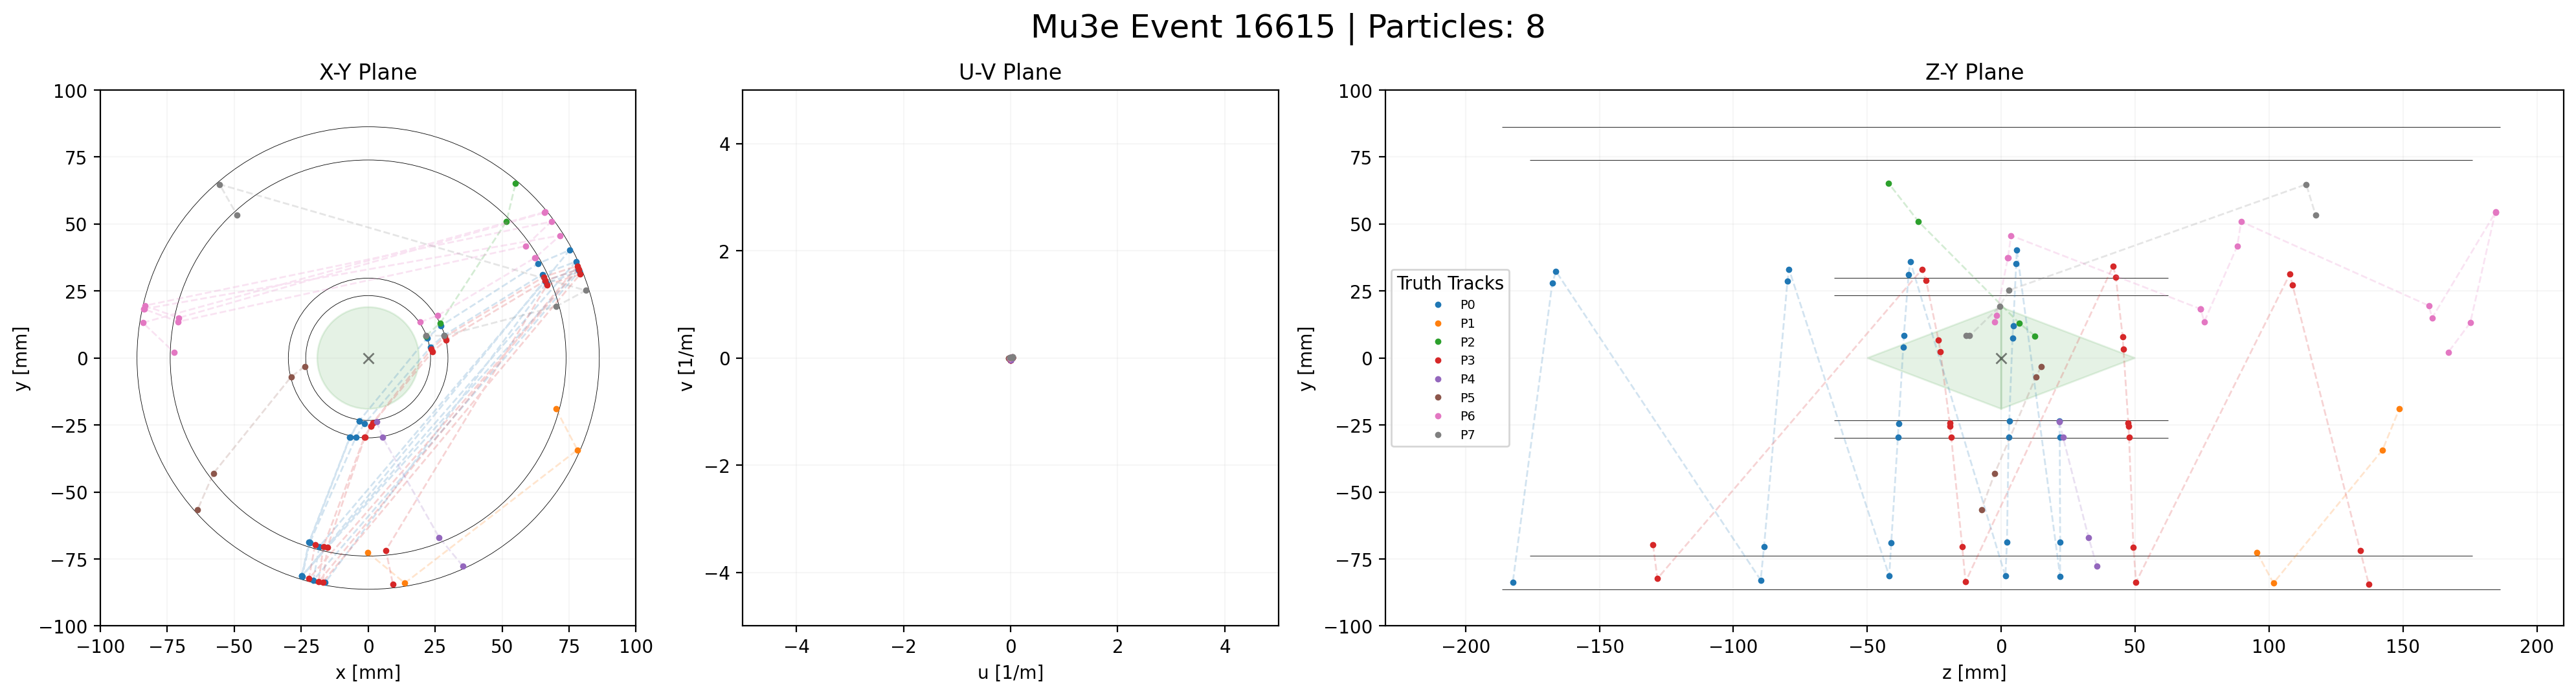

In [56]:
def plot_mu3e_tri_view(inputs, targets, batch_number):
    '''event visualiser - takes torch dataloader input and target dicts as input
       plots what model "sees"
       '''
    plt.style.use('default')

    # extract event id
    event_id = int(targets['sample_id'][batch_number].item()) # using sample_id from targets dict
    
    # setup figure
    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, 
        figsize=(20, 5.2), 
        dpi=200, 
        sharey=False, 
        gridspec_kw={'width_ratios': [1, 1, 2.2]}
    )
    
    # scale by 100 for mm scale
    h_x = inputs["hit_x"][batch_number].detach().cpu().numpy() #* 100
    h_y = inputs["hit_y"][batch_number].detach().cpu().numpy() #* 100
    h_z = inputs["hit_z"][batch_number].detach().cpu().numpy() #* 100

    # conformal mapping
    h_u = inputs["hit_u"][batch_number].detach().cpu().numpy()
    h_v = inputs["hit_v"][batch_number].detach().cpu().numpy()
    
    valid_mask = inputs["hit_valid"][batch_number].detach().cpu().numpy().astype(bool)

    # XY Plane
    ax1.set_title("X-Y Plane")
    ax1.set_xlim(-100, 100)
    ax1.set_ylim(-100, 100)
    ax1.set_aspect('equal')
    ax1.plot(0, 0, 'x', color='black', alpha=0.5)
    for r in [23.3, 29.8, 73.9, 86.3]:
        ax1.add_patch(Circle((0, 0), r, color='black', lw=0.3, fill=False))
    ax1.add_patch(Circle((0, 0), 19, color='green', alpha=0.1, label='Target'))

    # UV Plane
    ax2.set_title("U-V Plane")
    ax2.set_xlim(-5, 5)
    ax2.set_ylim(-5, 5)
    ax2.set_aspect('equal')

    # ZY Plane
    ax3.set_title("Z-Y Plane")
    ax3.set_xlim(-230, 210)
    ax3.set_ylim(-100, 100)
    ax3.set_aspect('equal')
    ax3.plot(0, 0, 'x', color='black', alpha=0.5)
    # detector layer Z-bounds (Phase I)
    ax3.hlines(y=[+23.3, -23.3], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax3.hlines(y=[+29.8, -29.8], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax3.hlines(y=[+73.9, -73.9], xmin=-175.95, xmax=175.95, color='black', lw=0.3)
    ax3.hlines(y=[+86.3, -86.3], xmin=-186.3,  xmax=186.3,  color='black', lw=0.3)
    
    # Mu3e Stopping Target
    tgt1 = Polygon(np.array([[-50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    tgt2 = Polygon(np.array([[50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    ax3.add_patch(tgt1)
    ax3.add_patch(tgt2)

    # 6. Plot Tracks
    p_hit_val = targets["particle_hit_valid"][batch_number].detach().cpu().numpy()
    p_valid = targets["particle_valid"][batch_number].detach().cpu().numpy().astype(bool)
    num_particles = np.sum(p_valid)
    
    for p_idx in range(p_hit_val.shape[0]):
        if not p_valid[p_idx]: 
            continue
        
        # Mask hits belonging to this particle that are also valid
        this_p_mask = p_hit_val[p_idx].astype(bool) & valid_mask
        if not np.any(this_p_mask): 
            continue
        
        x_p, y_p, z_p, u_p, v_p = h_x[this_p_mask], h_y[this_p_mask], h_z[this_p_mask], h_u[this_p_mask], h_v[this_p_mask]

        # Plot XY Projection
        line, = ax1.plot(x_p, y_p, '--', alpha=0.2, lw=1)
        color = line.get_color()
        ax1.plot(x_p, y_p, '.', color=color, markersize=5)

        # Plot UV Projection
        ax2.plot(u_p, v_p, '--', alpha=0.2, lw=1, color=color)
        ax2.plot(u_p, v_p, '.', color=color, markersize=5)

        # Plot ZY Projection
        ax3.plot(z_p, y_p, '--', alpha=0.2, lw=1, color=color)
        ax3.plot(z_p, y_p, '.', color=color, markersize=5, label=f'P{p_idx}')

    # 7. Labels & Polishing
    plt.suptitle(f'Mu3e Event {event_id} | Particles: {num_particles}', fontsize=18)
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    ax2.set_xlabel('u [1/m]')
    ax2.set_ylabel('v [1/m]')
    ax3.set_ylabel('y [mm]')
    ax3.set_xlabel('z [mm]')
    
    ax1.grid(alpha=0.1)
    ax2.grid(alpha=0.1)
    ax3.grid(alpha=0.1)
    ax3.legend(loc='center left', fontsize='x-small', title="Truth Tracks")
    
    plt.tight_layout()
    return fig

fig = plot_mu3e_tri_view(inputs, targets, 0)

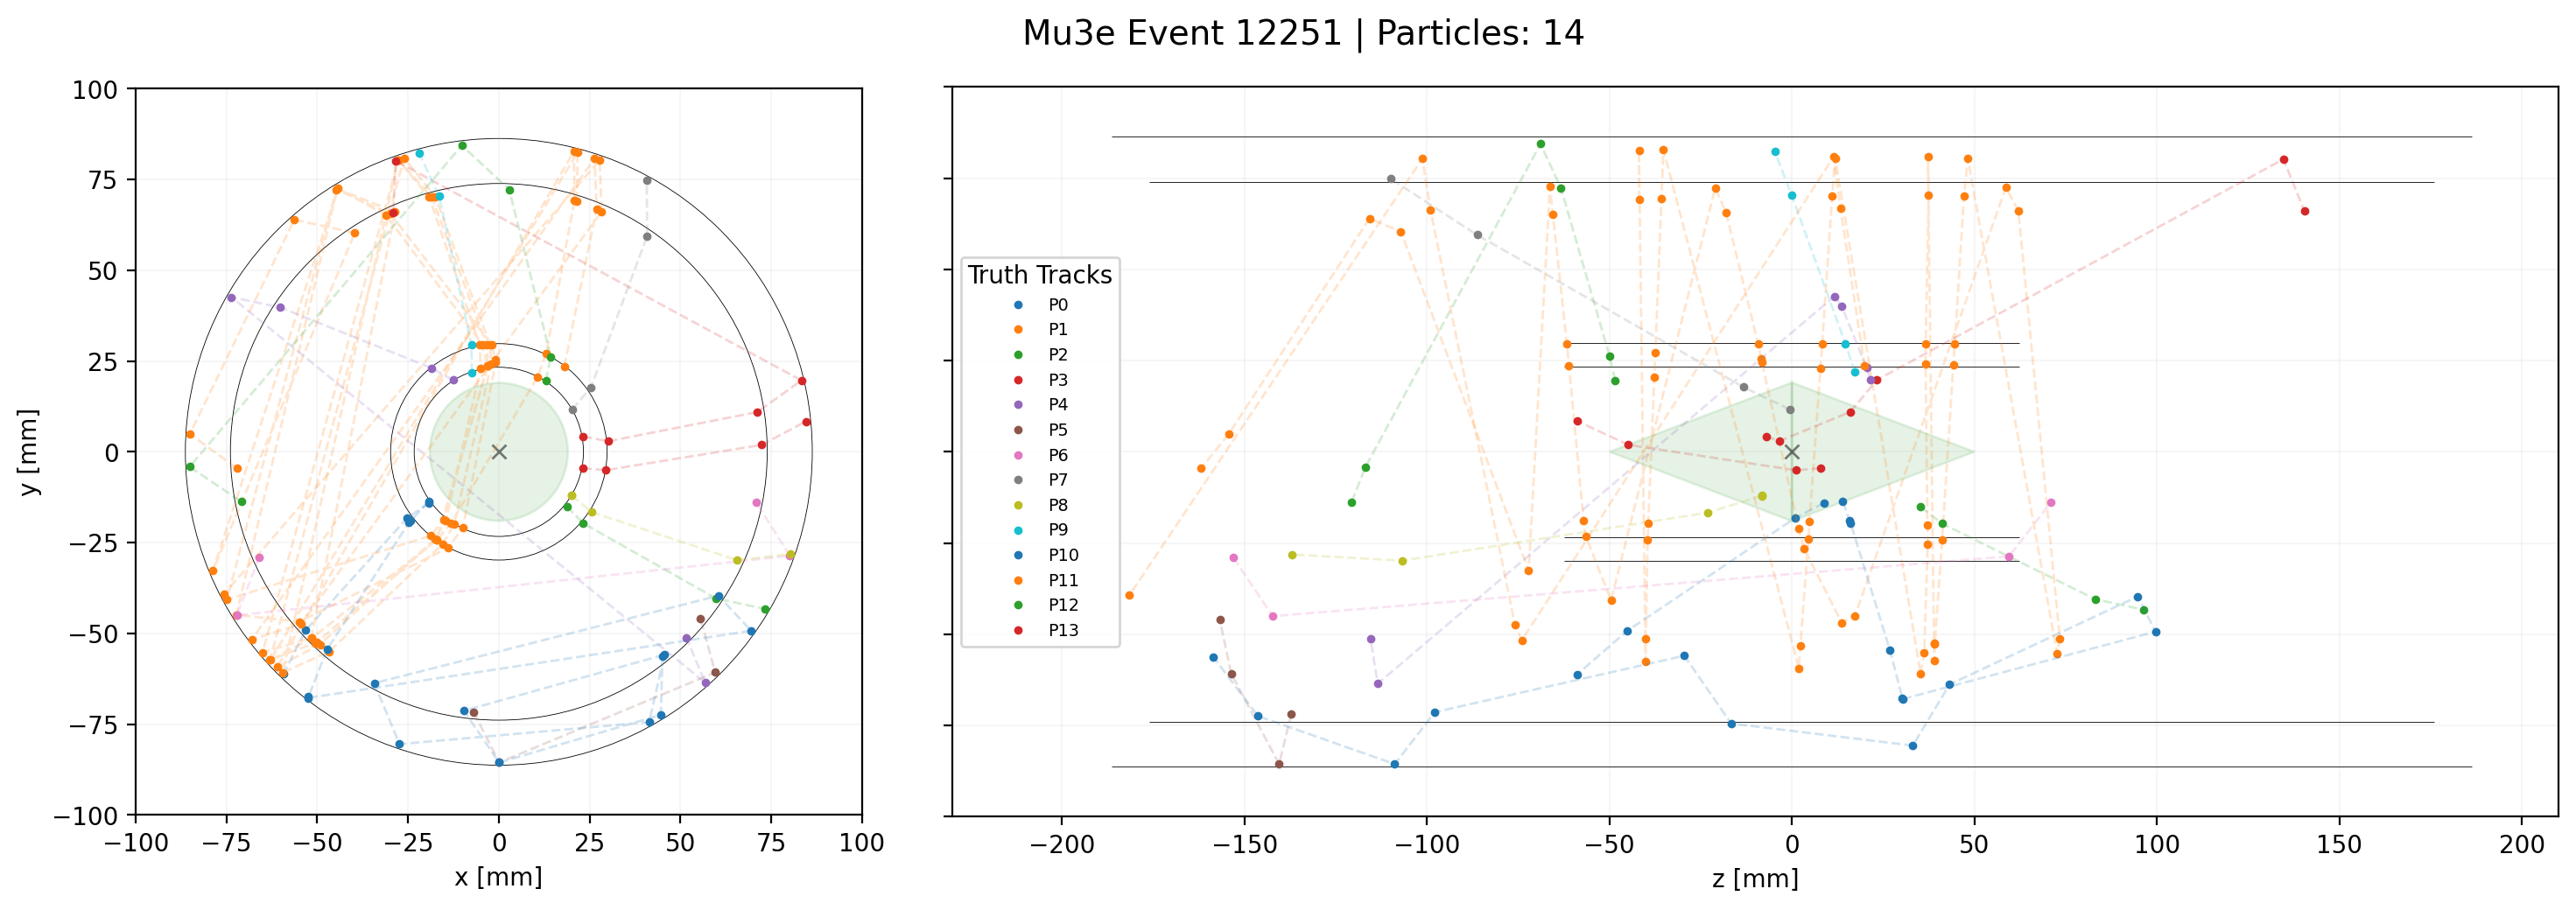

In [17]:
def plot_mu3e_dual_view(inputs, targets, batch_number):
    plt.style.use('default')

    # extract event id
    event_id = int(targets['sample_id'][batch_number].item()) # using sample_id from targets dict
    
    # setup figure
    fig, (ax1, ax2) = plt.subplots(
        1, 2, 
        figsize=(15, 5), 
        dpi=200, 
        sharey=True, 
        gridspec_kw={'width_ratios': [200, 460]}
    )
    
    # scale by 100 for mm scale
    h_x = inputs["hit_x"][batch_number].detach().cpu().numpy() * 100
    h_y = inputs["hit_y"][batch_number].detach().cpu().numpy() * 100
    h_z = inputs["hit_z"][batch_number].detach().cpu().numpy() * 100
    h_u = inputs["hit_u"][batch_number].detach().cpu().numpy()
    h_v = inputs["hit_v"][batch_number].detach().cpu().numpy()
    
    valid_mask = inputs["hit_valid"][batch_number].detach().cpu().numpy().astype(bool)

    # XY Plane
    ax1.set_xlim(-100, 100)
    ax1.set_ylim(-100, 100)
    ax1.set_aspect('equal')
    ax1.plot(0, 0, 'x', color='black', alpha=0.5)
    for r in [23.3, 29.8, 73.9, 86.3]:
        ax1.add_patch(Circle((0, 0), r, color='black', lw=0.3, fill=False))
    ax1.add_patch(Circle((0, 0), 19, color='green', alpha=0.1, label='Target'))

    # ZY Plane
    ax2.set_xlim(-230, 210)
    ax2.set_ylim(-100, 100)
    ax2.set_aspect('equal')
    ax2.plot(0, 0, 'x', color='black', alpha=0.5)
    # detector layer Z-bounds (Phase I)
    ax2.hlines(y=[+23.3, -23.3], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+29.8, -29.8], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+73.9, -73.9], xmin=-175.95, xmax=175.95, color='black', lw=0.3)
    ax2.hlines(y=[+86.3, -86.3], xmin=-186.3,  xmax=186.3,  color='black', lw=0.3)
    
    # Mu3e Stopping Target
    tgt1 = Polygon(np.array([[-50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    tgt2 = Polygon(np.array([[50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    ax2.add_patch(tgt1)
    ax2.add_patch(tgt2)

    # 6. Plot Tracks
    p_hit_val = targets["particle_hit_valid"][batch_number].detach().cpu().numpy()
    p_valid = targets["particle_valid"][batch_number].detach().cpu().numpy().astype(bool)
    num_particles = np.sum(p_valid)
    
    for p_idx in range(p_hit_val.shape[0]):
        if not p_valid[p_idx]: 
            continue
        
        # Mask hits belonging to this particle that are also valid
        this_p_mask = p_hit_val[p_idx].astype(bool) & valid_mask
        if not np.any(this_p_mask): 
            continue
        
        x_p, y_p, z_p, u_p, v_p = h_x[this_p_mask], h_y[this_p_mask], h_z[this_p_mask], h_u[this_p_mask], h_v[this_p_mask]

        # Plot XY Projection
        line, = ax1.plot(x_p, y_p, '--', alpha=0.2, lw=1)
        color = line.get_color()
        ax1.plot(x_p, y_p, '.', color=color, markersize=5)

        # Plot UV Projection
        #ax2.plot(u_p, v_p, '.', color=color, markersize=5)

        # Plot ZY Projection
        ax2.plot(z_p, y_p, '--', alpha=0.2, lw=1, color=color)
        ax2.plot(z_p, y_p, '.', color=color, markersize=5, label=f'P{p_idx}')

    # 7. Labels & Polishing
    plt.suptitle(f'Mu3e Event {event_id} | Particles: {num_particles}', fontsize=14)
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    ax2.set_xlabel('z [mm]')
    ax1.grid(alpha=0.1)
    ax2.grid(alpha=0.1)
    ax2.legend(loc='center left', fontsize='x-small', title="Truth Tracks")
    
    plt.tight_layout()
    return fig

fig = plot_mu3e_dual_view(inputs, targets, 0)

### `field histograms`

In [133]:
print('input keys:', inputs.keys())
print('target keys:', targets.keys())
print()
print('config keys:', config.keys())

input keys: dict_keys(['hit_valid', 'hit_x', 'hit_y', 'hit_z', 'hit_r', 'hit_s', 'hit_lambda', 'hit_coslambda', 'hit_sinlambda', 'hit_phi', 'hit_cosphi', 'hit_sinphi', 'hit_eta', 'hit_u', 'hit_v', 'hit_hitID'])
target keys: dict_keys(['hit_valid', 'particle_valid', 'particle_hit_valid', 'sample_id', 'particle_pt', 'particle_signed_pt', 'particle_sinphi', 'particle_cosphi', 'particle_sinlambda', 'particle_coslambda'])

config keys: dict_keys(['seed_everything', 'name', 'data', 'trainer', 'model'])


In [9]:
input_keys = ['hit_' + field for field in config['data']['inputs']['hit']]
target_keys = ['particle_' + field for field in config['data']['targets']['particle']]

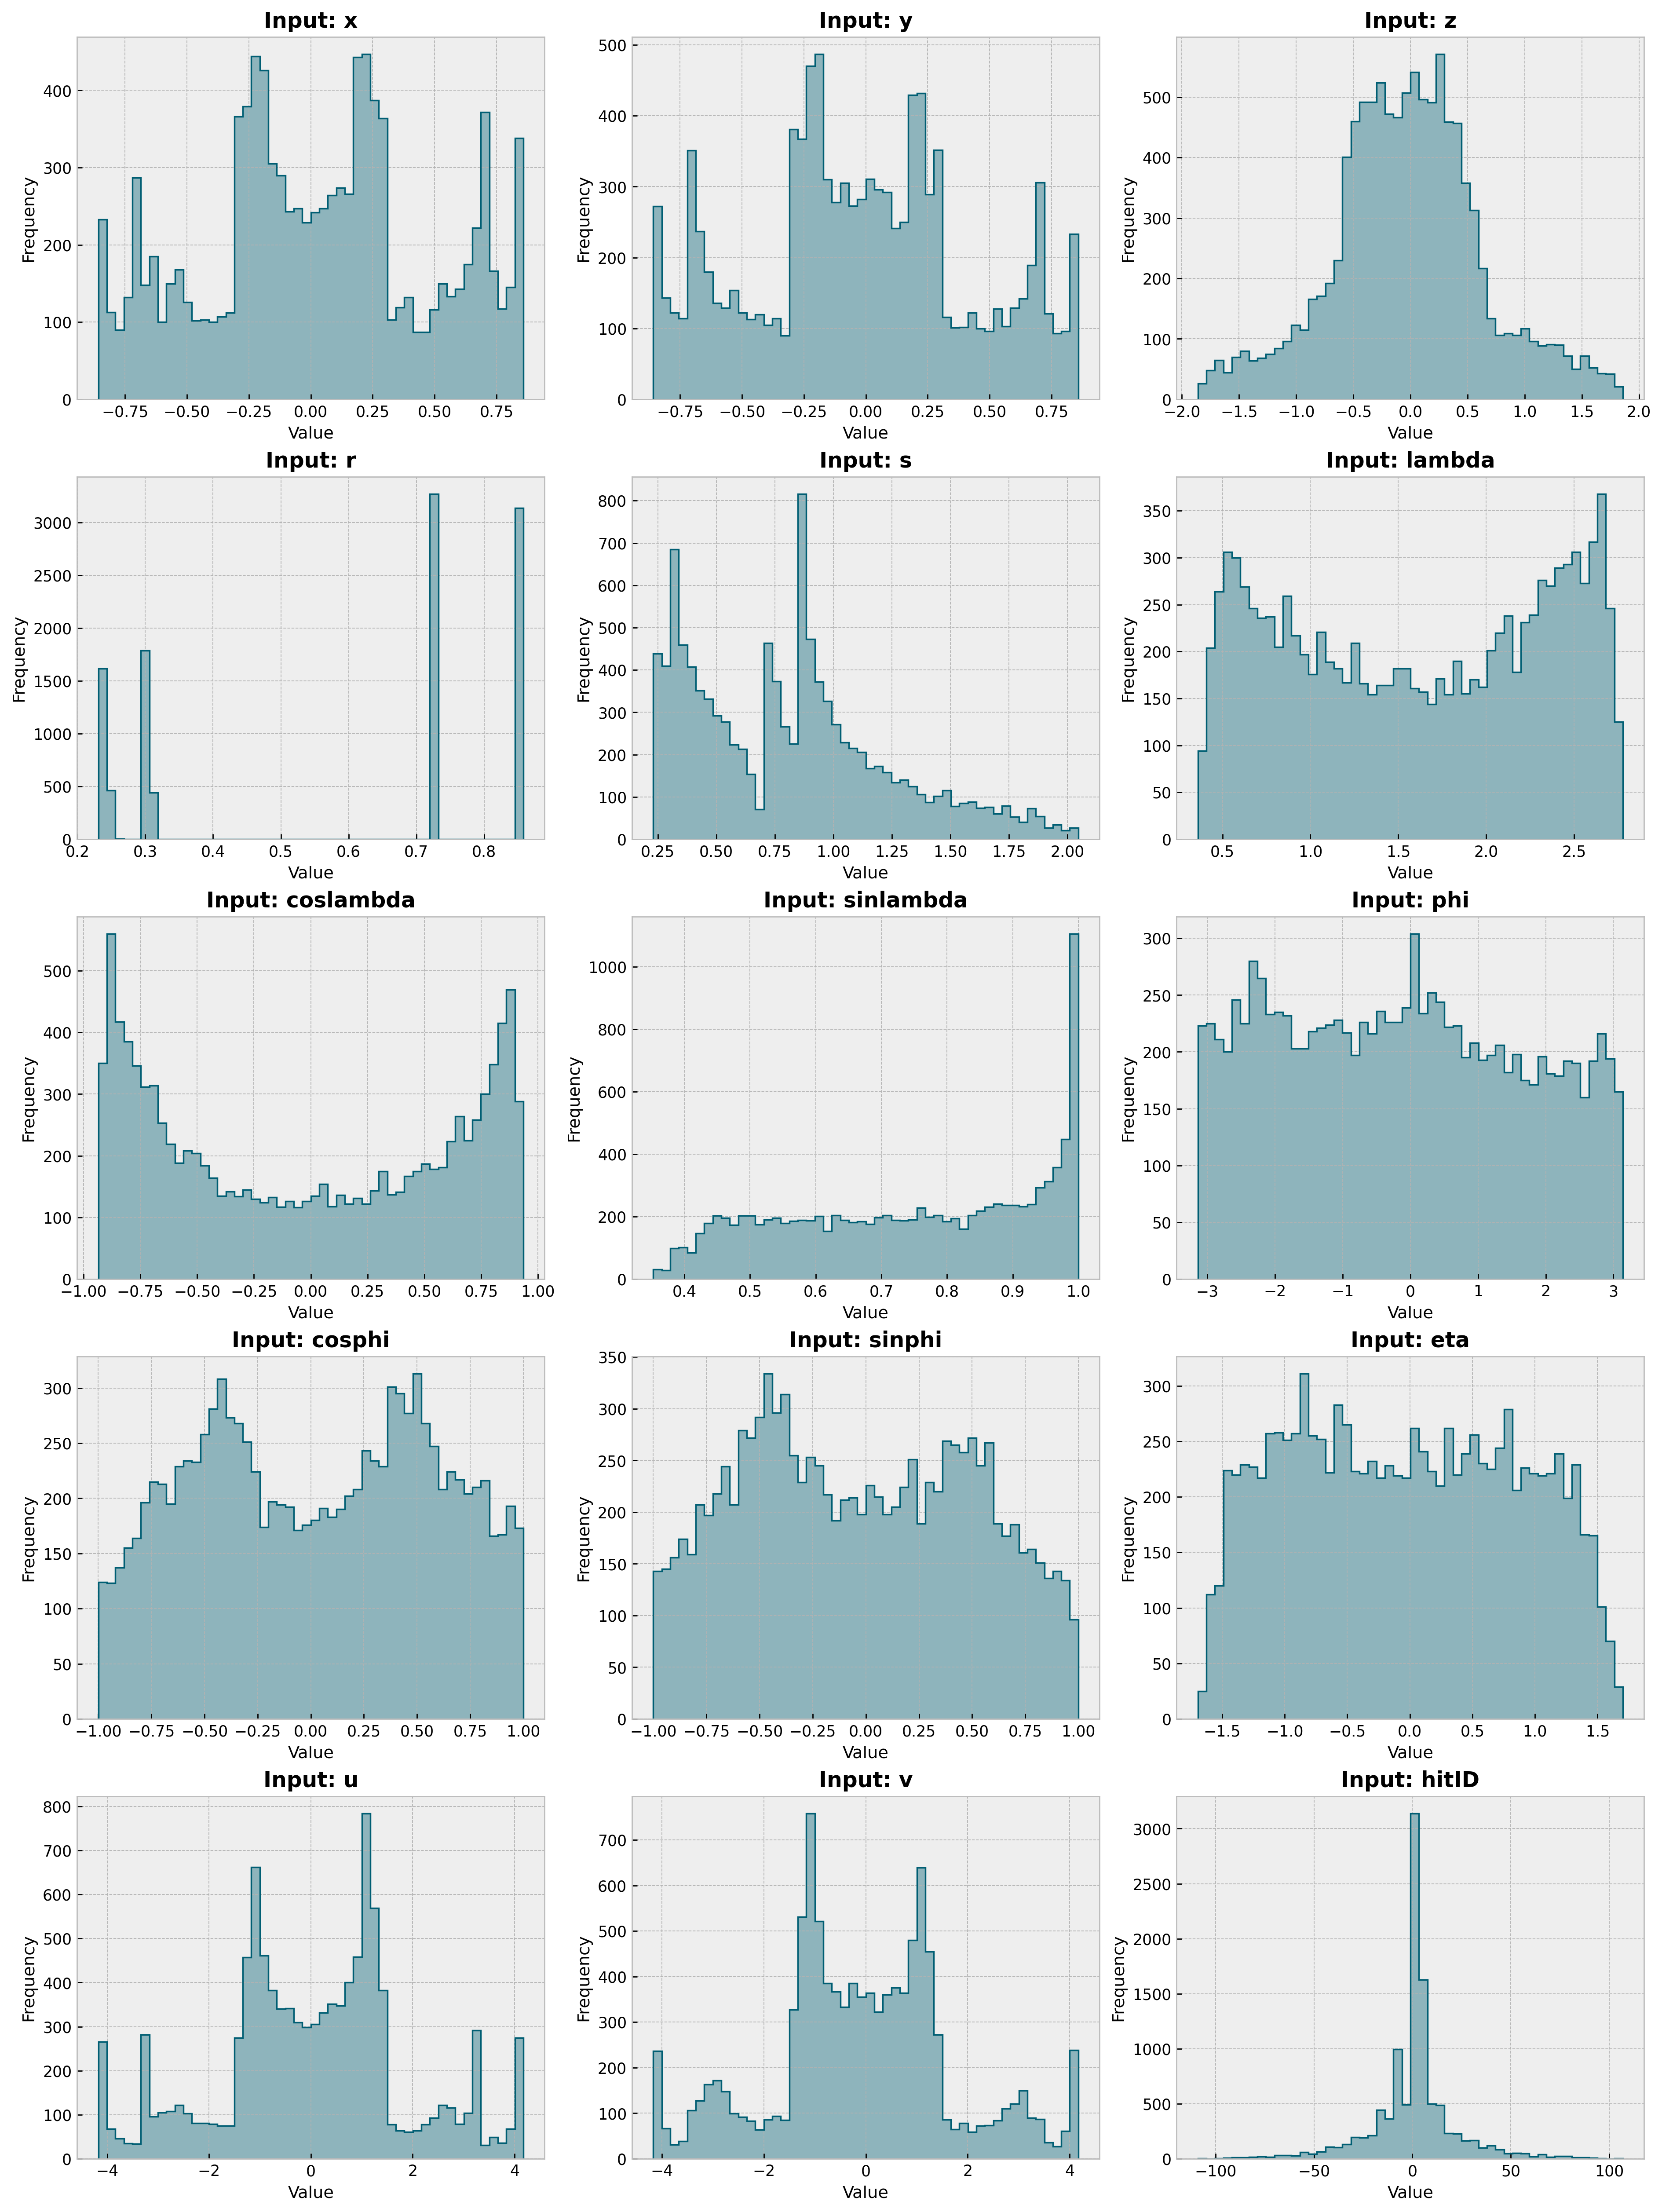

In [134]:
# Setup fields and grid
hit_fields = config['data']['inputs']['hit']
n_fields = len(hit_fields)
cols = 3
rows = math.ceil(n_fields / cols)

# Using high-quality style settings
plt.style.use('bmh')
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), dpi=250, constrained_layout=True)
axes = axes.flatten()

# Mask for valid hits
mask = inputs['hit_valid'].bool()

for i, field in enumerate(hit_fields):
    key = 'hit_' + field
    data = inputs[key][mask].float().cpu().numpy()
    data = data[np.isfinite(data)]
    
    ax = axes[i]

    bins = 50
    main_color = '#005E73' 

    # plotting
    ax.hist(data, bins=bins, histtype='step', linewidth=1, color=main_color)
    ax.hist(data, bins=bins, histtype='stepfilled', alpha=0.4, color=main_color)
    
    # Formatting
    ax.set_title(f'Input: {field}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)

# 3. Clean up unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

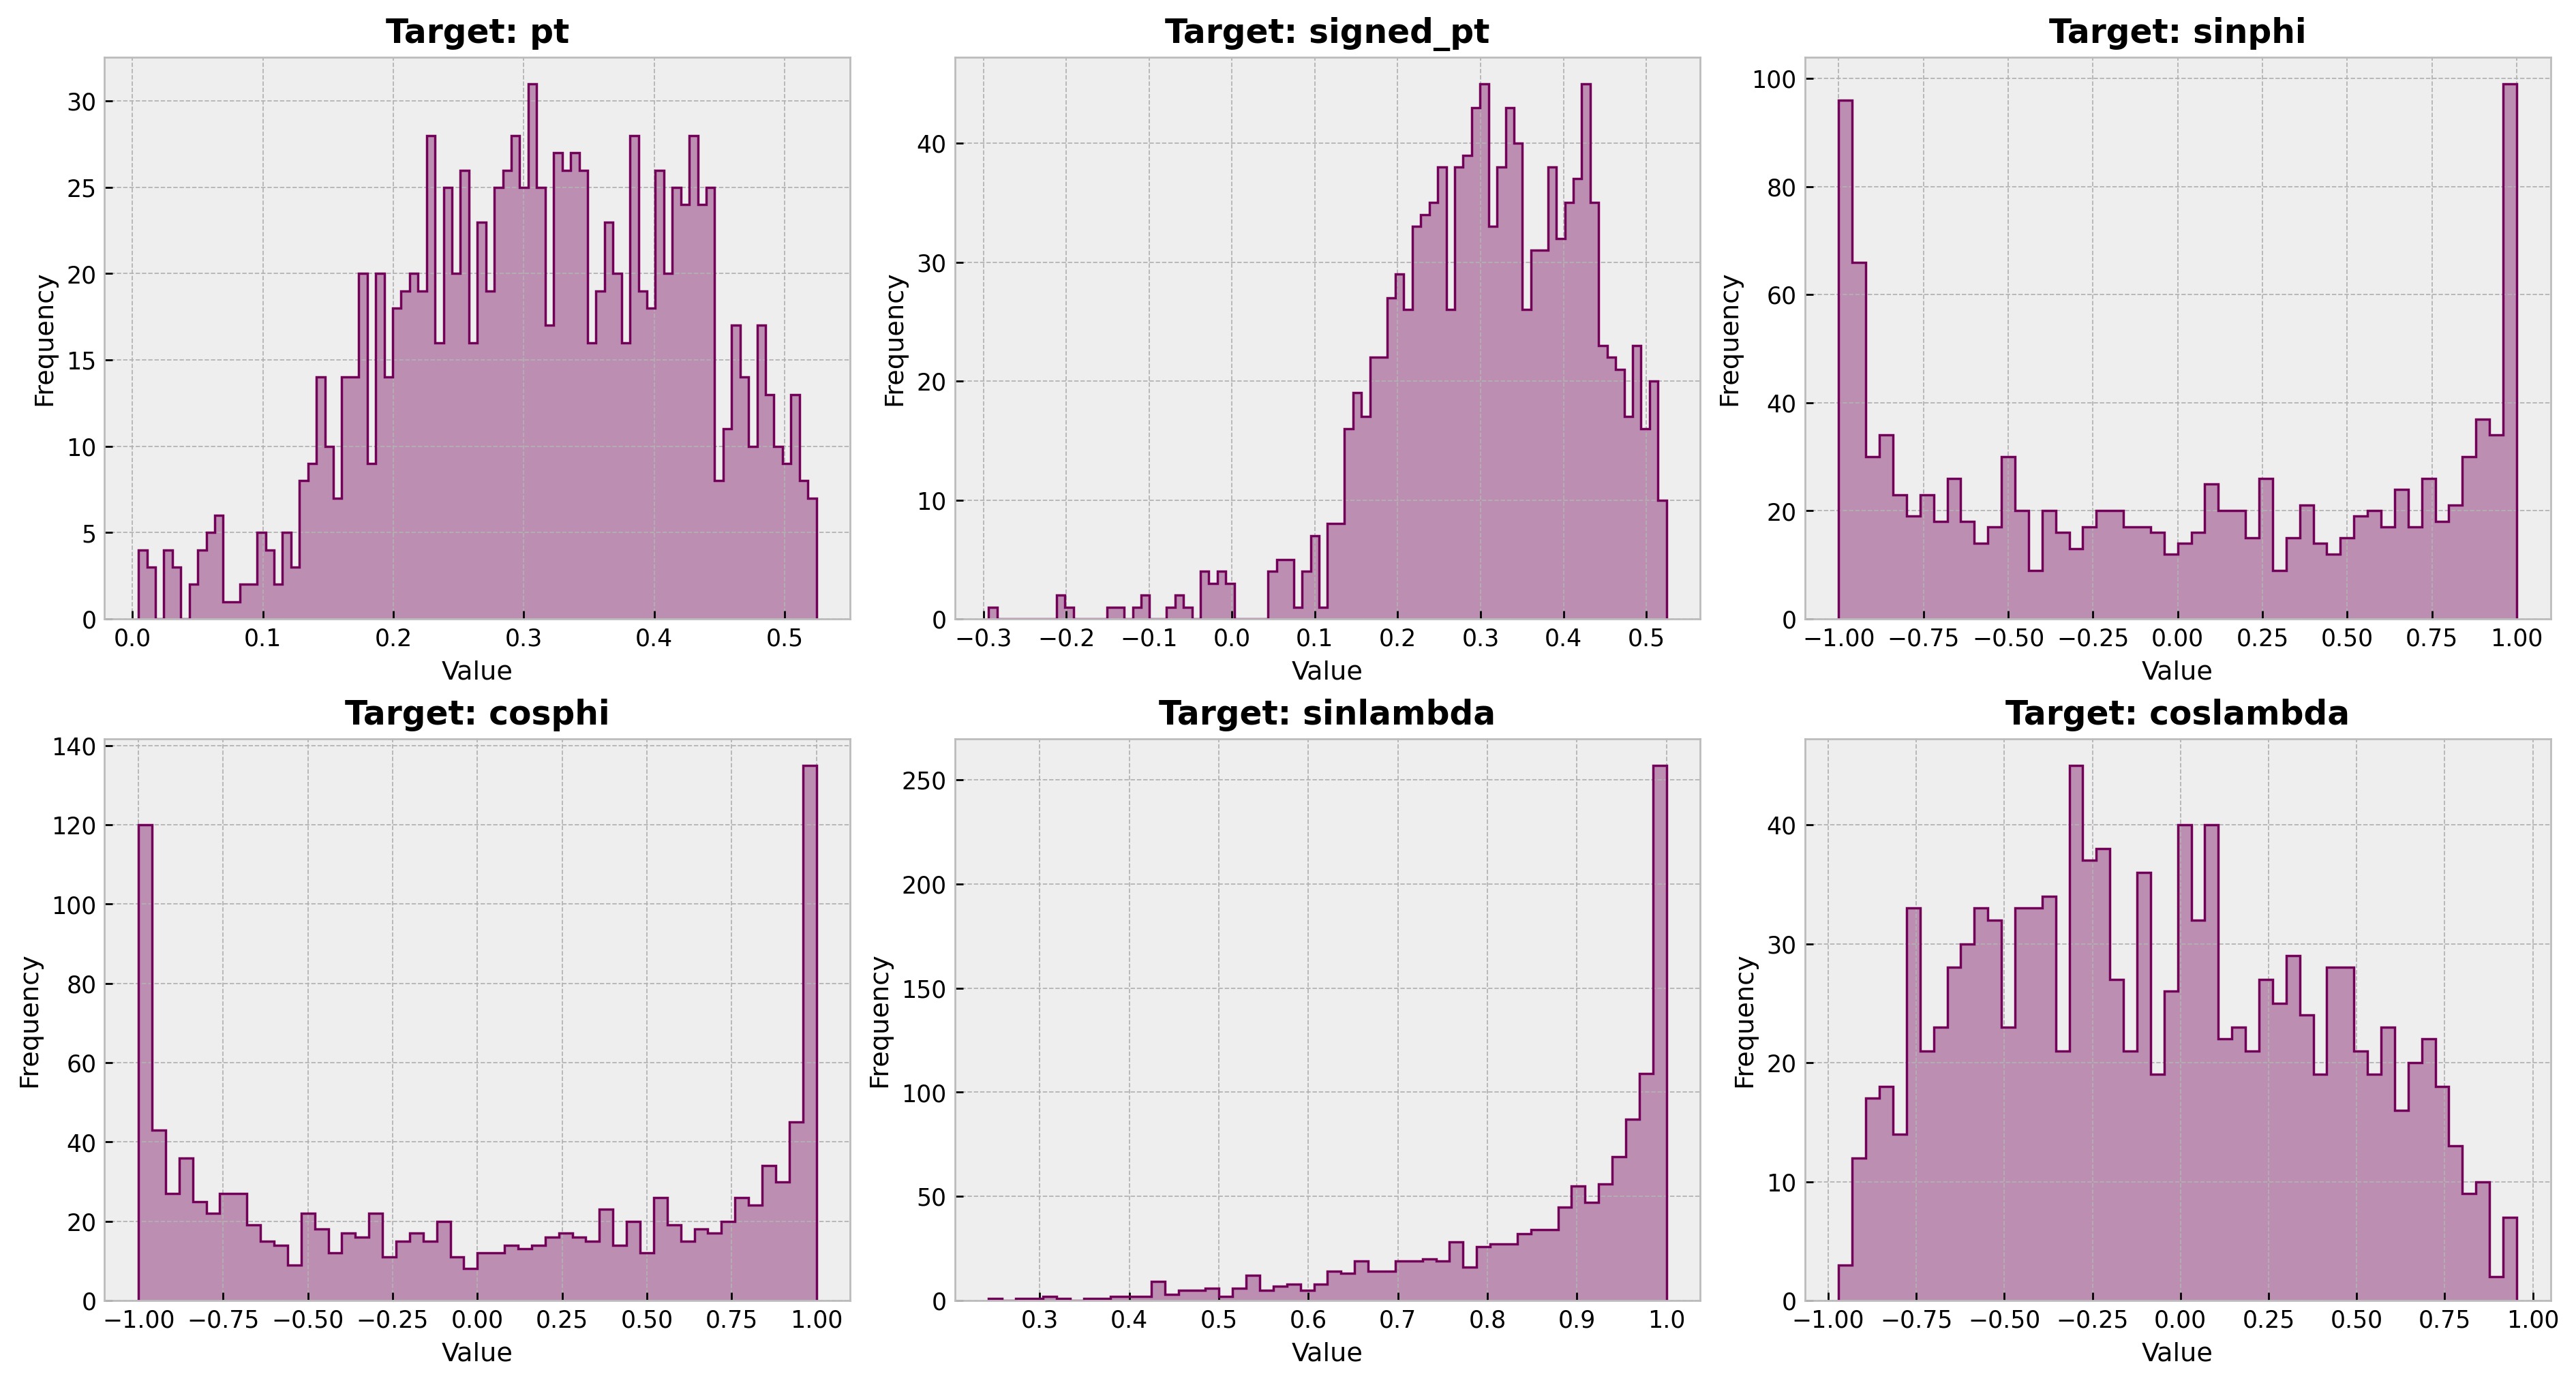

In [121]:
# 1. Setup fields and grid
particle_fields = config['data']['targets']['particle']
n_fields = len(particle_fields)
cols = 3
rows = math.ceil(n_fields / cols)

# Using high-quality style settings
plt.style.use('bmh')
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), dpi=250, constrained_layout=True)
axes = axes.flatten()

# Mask for valid particles
mask = targets['particle_valid'].bool()

for i, field in enumerate(particle_fields):
    key = 'particle_' + field
    data = targets[key][mask].float().cpu().numpy()
    data = data[np.isfinite(data)]
    
    ax = axes[i]

    bins = 80 if field in ['pt', 'signed_pt'] else 50
    main_color = '#730058'
    
    # plotting
    ax.hist(data, bins=bins, histtype='step', linewidth=1, color=main_color)
    ax.hist(data, bins=bins, histtype='stepfilled', alpha=0.4, color=main_color)
    
    # formatting
    ax.set_title(f'Target: {field}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)

# 3. Clean up unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

In [ ]:
# Prepare combined fields list
combined_fields = [ (f, 'hit') for f in config['data']['inputs']['hit'] ] + \
                  [ (f, 'target') for f in config['data']['targets']['particle'] ]

n_fields = len(combined_fields)
cols = 3  
rows = math.ceil(n_fields / cols)

plt.style.use('bmh')
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), dpi=250, constrained_layout=True)
axes = axes.flatten()

for i, (field, f_type) in enumerate(combined_fields):
    ax = axes[i]
    
    if f_type == 'hit':
        key = 'hit_' + field
        data = inputs[key][inputs['hit_valid'].bool()].float().cpu().numpy()
        color = '#005E73' 
        title_prefix = 'Hit'
        bins = 50
    else:
        key = 'particle_' + field
        data = targets[key][targets['particle_valid'].bool()].float().cpu().numpy()
        color = '#730058'
        title_prefix = 'Target'
        bins = 80 if field in ['pt', 'signed_pt'] else 50

    # Clean data for plotting
    data = data[np.isfinite(data)]
    
    # Plotting: Step + Filled style
    ax.hist(data, bins=bins, histtype='step', linewidth=1, color=color)
    ax.hist(data, bins=bins, histtype='stepfilled', alpha=0.4, color=color)
    
    # Formatting
    ax.set_title(f'{title_prefix}: {field}', fontsize=12, fontweight='bold', color=color)
    ax.tick_params(axis='both', which='major', labelsize=9)
    #ax.grid(linestyle='--', alpha=0.2)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()
#plt.savefig('model_field_distribution_superplot.png')